# EDA — Sales & Demand Forecasting (Walmart)

**AIO Conquer 2026 — Module 03 · Project 3.2**

**Muc dich:** hieu sau ve dataset va domain (khong phai tim feature cuoi cung) truoc khi
buoc vao Giai doan 5 (Model Training day du). Notebook nay chi kham pha/truc quan hoa
(CLAUDE.md muc 4 rule 8) — **khong chua logic san xuat**, khong duoc import vao `src/`
hay `pipelines/`. Moi phat hien quan trong can duoc "tot nghiep" thanh ghi chu trong
`docs/00_decisions.md` hoac test trong `tests/` truoc khi coi la chinh thuc.

**Pham vi:** dung lai loader/validator/aggregate that trong `src/sales_forecast/` (khong
tu viet lai `pd.read_csv`/logic join rieng) de dam bao du lieu trong notebook khop 100%
voi du lieu ma pipeline production dang dung.

**Cau truc:**
0. Setup & Data Contract check
1. Tong quan tung bang (doi chieu so lieu da biet trong `docs/01_ideation.md`)
2. Chuoi thoi gian o granularity (Store, Date) hien tai — trong tam chinh
3. Autocorrelation & tinh hop ly cua lag/rolling da chon
4. Bien ngoai sinh (Macro & MarkDown) — quan he voi target
5. Kiem tra truc quan cac rang buoc thoi gian (bo tro cho tests/)
6. Error-analysis-readiness — cac nhom cat lat tiem nang
7. Tong hop phat hien moi → viec can lam tiep


## 0. Setup & Data Contract check

Load 4 CSV qua `sales_forecast.ingestion.loaders.load_raw_data`, chay `validate_*_schema`
de xac nhan notebook dang dung dung du lieu da pass Data Contract — khong tu parse CSV
rieng trong notebook (tranh lech logic voi pipeline chinh).

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# Khong dung Path.cwd() de tinh REPO_ROOT -- cwd cua kernel Jupyter trong VSCode khong
# on dinh (co the la thu muc chua notebook, co the la workspace root, tuy cach khoi
# dong kernel), tung gay AssertionError sai du .venv van dung. Dung bien built-in
# __vsc_ipynb_file__ (VSCode notebook kernel bom vao globals) de lay duong dan file
# notebook truc tiep, on dinh voi moi cwd.
try:
    NOTEBOOK_DIR = Path(__vsc_ipynb_file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT = NOTEBOOK_DIR.parent
sys.path.insert(0, str(REPO_ROOT / "src"))

# Kiem tra kernel dang chay dung .venv cua repo TRUOC khi import sales_forecast --
# neu kernel sai, day se bao AssertionError ro rang thay vi ModuleNotFoundError kho hieu.
# Neu fail: VSCode > Ctrl+Shift+P > "Notebook: Select Kernel" > chon
# .venv/Scripts/python.exe trong thu muc repo, roi Restart Kernel va chay lai tu dau.
# So sanh .lower(): tren Windows, o dia co the tra ve "D:" hoac "d:" tuy vao kernel duoc
# khoi dong the nao (venv activate vs. VSCode tu spawn) -- filesystem khong phan biet
# hoa/thuong nhung phep so sanh string "in" thi co, nen phai chuan hoa truoc khi so sanh.
expected_venv = REPO_ROOT / ".venv"
assert str(expected_venv).lower() in sys.executable.lower(), (
    f"Kernel dang dung sai Python: {sys.executable}\n"
    f"Can chon kernel tro toi: {expected_venv / 'Scripts' / 'python.exe'}"
)

from sales_forecast.ingestion.loaders import load_raw_data, aggregate_to_store_date
from sales_forecast.ingestion.validators import (
    validate_train_schema,
    validate_test_schema,
    validate_features_schema,
    validate_stores_schema,
    validate_train_aggregated_schema,
    validate_test_aggregated_schema,
)

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["figure.dpi"] = 100

COLOR_HOLIDAY = "#DD8452"
COLOR_NORMAL = "#4C72B0"
COLOR_ACCENT = "#55A868"
COLOR_MUTED = "#8C9BAE"

In [2]:
# pandera da duoc dam bao dung .venv o cell truoc (assert sys.executable) --
# o day chi con kiem tra version pandera khop pin trong pyproject.toml.
import pandera
assert pandera.__version__.startswith("0.19"), (
    f"pandera version khong khop pyproject.toml (can 0.19.x, dang co {pandera.__version__}) "
    f"-- kiem tra lai kernel/venv."
)

print(f"OK - sys.executable: {sys.executable}")
print(f"OK - pandera version: {pandera.__version__}")

OK - sys.executable: D:\Claude_code_sandbox\AIO_Conquer_Module 3\Project_Module3\.venv\Scripts\python.exe
OK - pandera version: 0.19.3


In [3]:
raw = load_raw_data(REPO_ROOT / "data" / "raw")

validate_train_schema(raw["train"])
validate_test_schema(raw["test"])
validate_features_schema(raw["features"])
validate_stores_schema(raw["stores"])

for name, df in raw.items():
    print(f"{name:10s}: {df.shape}")

train     : (421570, 5)
test      : (115064, 4)
features  : (8190, 12)
stores    : (45, 3)


In [4]:
# Aggregate ve (Store, Date) — dung dung ham production, khong tu viet lai groupby
train_agg, test_agg = aggregate_to_store_date(raw["train"], raw["test"])
validate_train_aggregated_schema(train_agg)
validate_test_aggregated_schema(test_agg)

print(f"train (raw, Store-Dept-Date): {raw['train'].shape}")
print(f"train (aggregated, Store-Date): {train_agg.shape}")
print(f"test  (raw, Store-Dept-Date): {raw['test'].shape}")
print(f"test  (aggregated, Store-Date): {test_agg.shape}")

train (raw, Store-Dept-Date): (421570, 5)


train (aggregated, Store-Date): (6435, 4)
test  (raw, Store-Dept-Date): (115064, 4)
test  (aggregated, Store-Date): (1755, 3)


## 1. Tong quan tung bang

Doi chieu nhanh voi bang da co trong `docs/01_ideation.md` muc 2 — muc tieu la *xac nhan
bang mat qua bieu do*, khong phai kham pha lai tu dau.

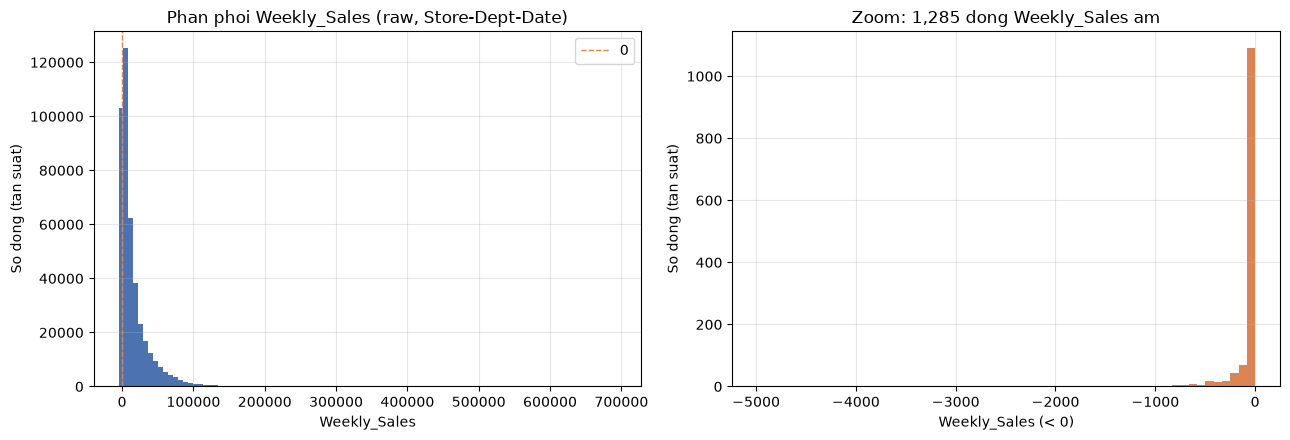

So dong am: 1,285
So dong = 0: 73


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(raw["train"]["Weekly_Sales"], bins=100, color=COLOR_NORMAL)
axes[0].set_title("Phan phoi Weekly_Sales (raw, Store-Dept-Date)")
axes[0].set_xlabel("Weekly_Sales")
axes[0].set_ylabel("So dong (tan suat)")
axes[0].axvline(0, color=COLOR_HOLIDAY, ls="--", lw=1, label="0")
axes[0].legend()

neg = raw["train"][raw["train"]["Weekly_Sales"] < 0]["Weekly_Sales"]
axes[1].hist(neg, bins=60, color=COLOR_HOLIDAY)
axes[1].set_title(f"Zoom: {len(neg):,} dong Weekly_Sales am")
axes[1].set_xlabel("Weekly_Sales (< 0)")
axes[1].set_ylabel("So dong (tan suat)")

fig.tight_layout()
plt.show()

print(f"So dong am: {(raw['train']['Weekly_Sales'] < 0).sum():,}")
print(f"So dong = 0: {(raw['train']['Weekly_Sales'] == 0).sum():,}")

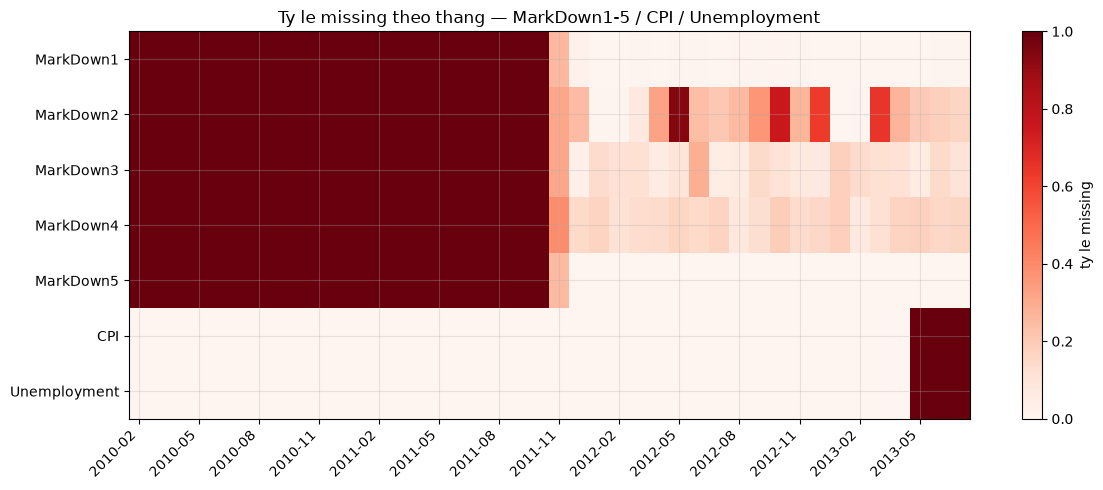

In [6]:
# Missing-value heatmap cho features.csv theo thoi gian (MNAR pattern)
markdown_cols = [c for c in raw["features"].columns if c.startswith("MarkDown")]
missing_by_month = (
    raw["features"]
    .assign(year_month=raw["features"]["Date"].dt.to_period("M"))
    .groupby("year_month")[markdown_cols + ["CPI", "Unemployment"]]
    .apply(lambda g: g.isna().mean())
)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(missing_by_month.T.values, aspect="auto", cmap="Reds", vmin=0, vmax=1)
ax.set_yticks(range(len(missing_by_month.columns)))
ax.set_yticklabels(missing_by_month.columns)
step = 3
xticks = range(0, len(missing_by_month), step)
ax.set_xticks(list(xticks))
ax.set_xticklabels([str(missing_by_month.index[i]) for i in xticks], rotation=45, ha="right")
ax.set_title("Ty le missing theo thang — MarkDown1-5 / CPI / Unemployment")
fig.colorbar(im, ax=ax, label="ty le missing")
fig.tight_layout()
plt.show()

## 2. Chuoi thoi gian o granularity (Store, Date) hien tai — trong tam chinh

Don vi du bao hien tai la (Store, Date) — xem `docs/00_decisions.md` [2026-08-19]
"Doi don vi du bao". Phan nay tap trung hieu hanh vi cua 45 chuoi Store sau aggregate.

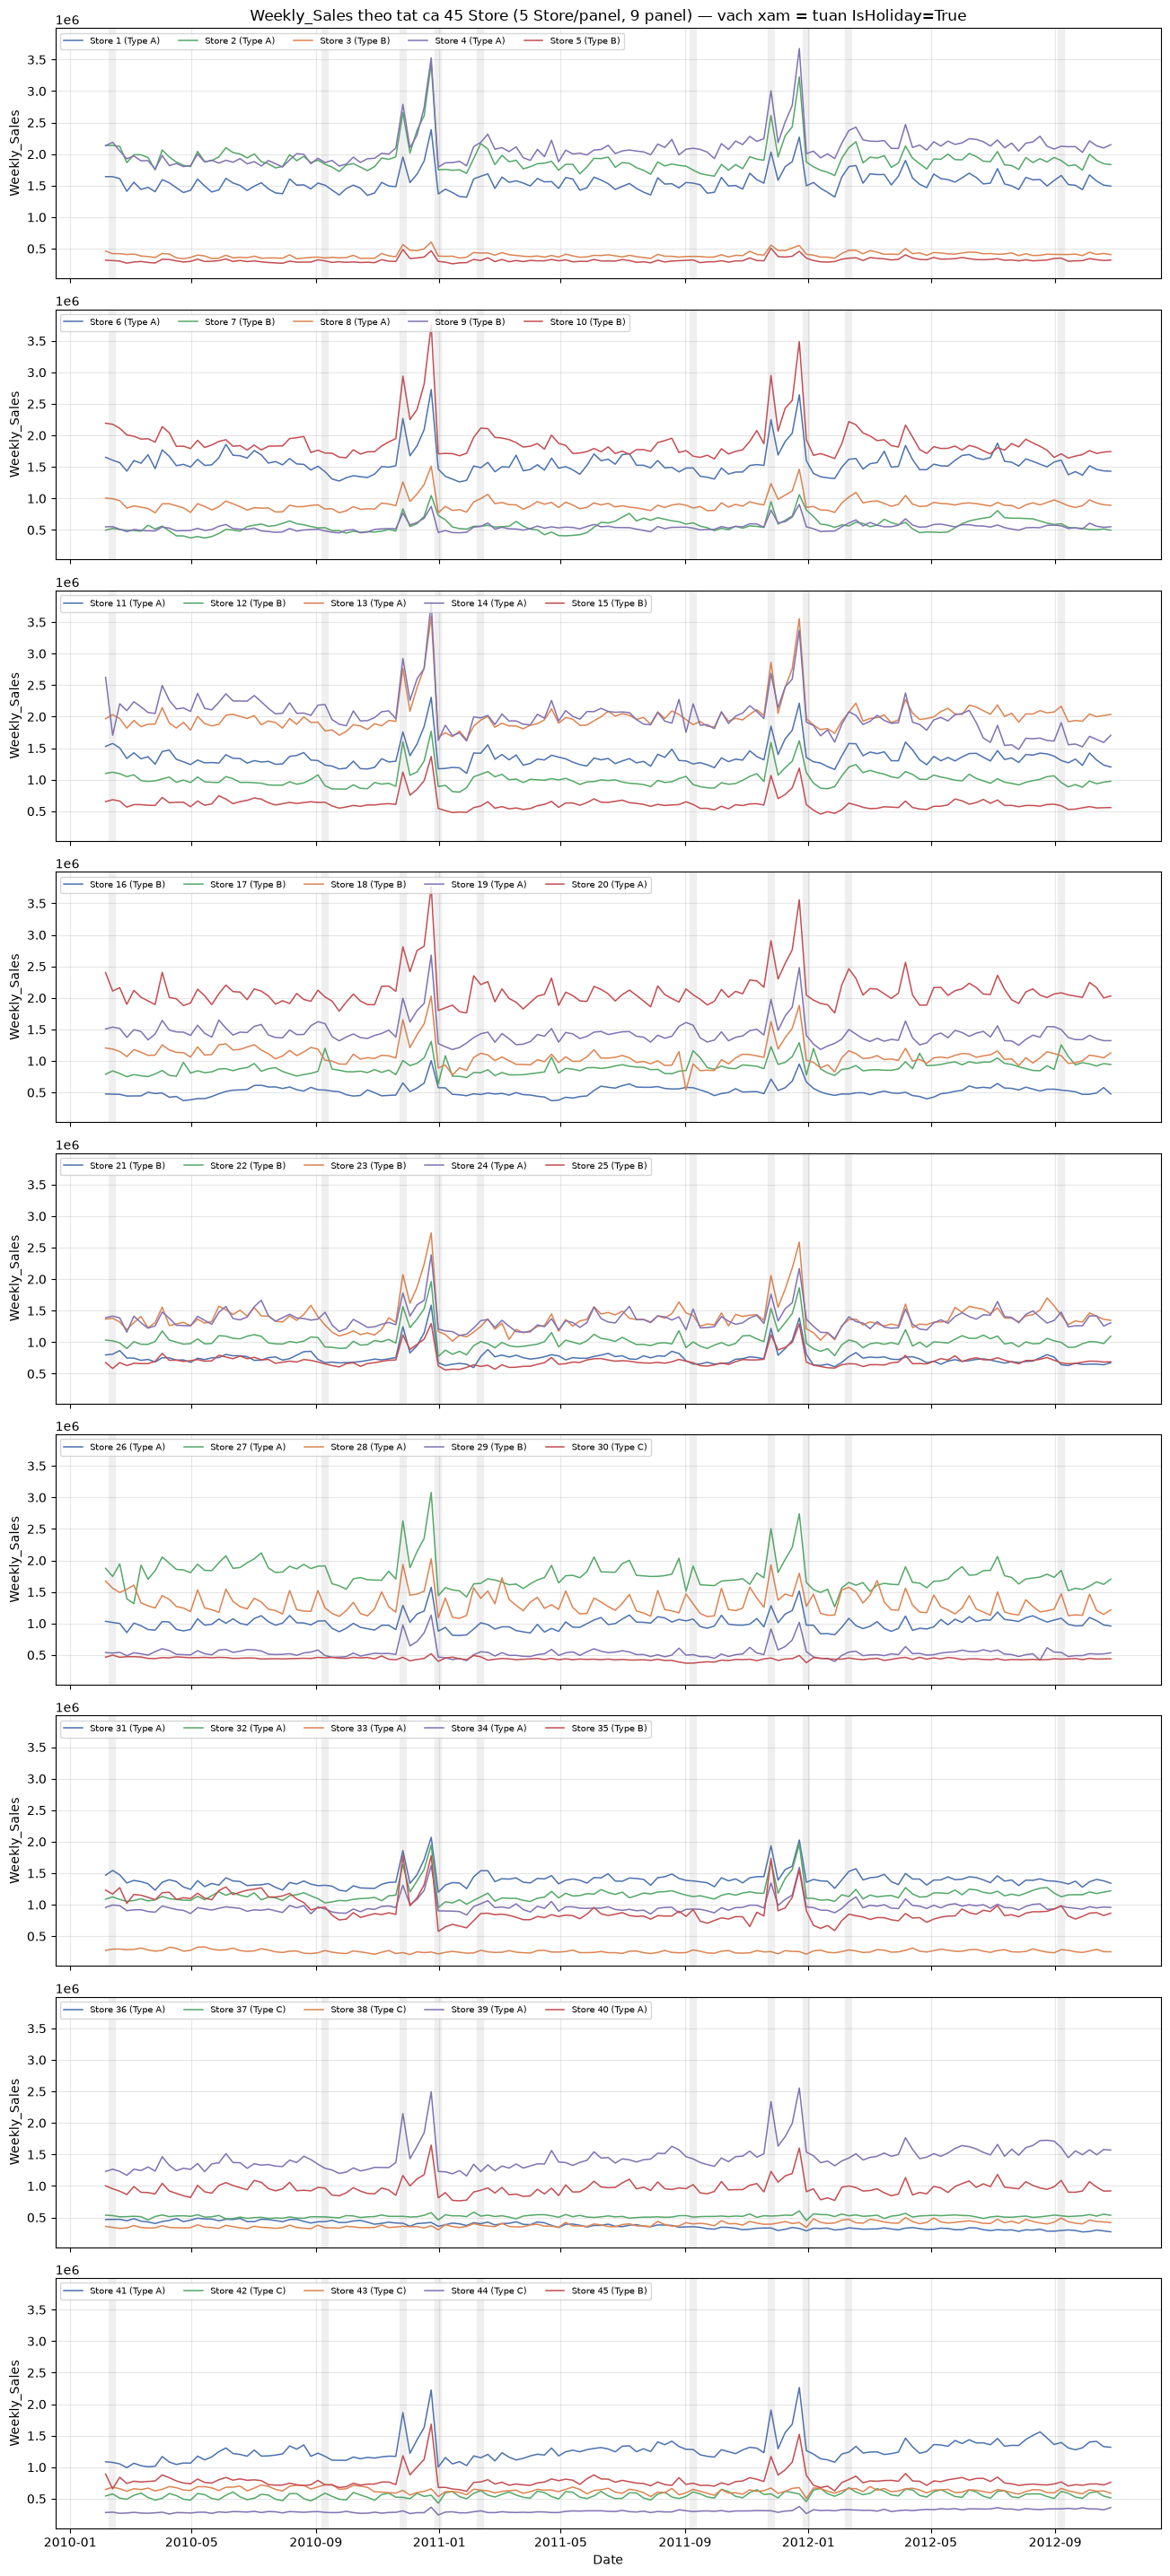

In [7]:
train_plot = train_agg.merge(raw["stores"], on="Store")

# Ve DU 45 Store, chia 5 Store/bieu do (9 subplot = 45/5) de doc duoc tung duong,
# thay vi chi 4 Store mau nhu truoc — sharex/sharey de so sanh bien do giua cac nhom.
all_stores = sorted(train_plot["Store"].unique())
stores_per_panel = 5
n_panels = int(np.ceil(len(all_stores) / stores_per_panel))
panel_colors = [COLOR_NORMAL, COLOR_ACCENT, COLOR_HOLIDAY, "#8172B3", "#C44E52"]

holiday_dates = sorted(train_agg.loc[train_agg["IsHoliday"], "Date"].unique())

fig, axes = plt.subplots(n_panels, 1, figsize=(13, 3.2 * n_panels), sharex=True, sharey=True)
axes = np.atleast_1d(axes)

for panel_idx in range(n_panels):
    ax = axes[panel_idx]
    panel_stores = all_stores[panel_idx * stores_per_panel : (panel_idx + 1) * stores_per_panel]

    for store_id, c in zip(panel_stores, panel_colors):
        sub = train_plot[train_plot["Store"] == store_id].sort_values("Date")
        store_type = sub["Type"].iloc[0]
        ax.plot(sub["Date"], sub["Weekly_Sales"], label=f"Store {store_id} (Type {store_type})", color=c, lw=1.1)

    for d in holiday_dates:
        ax.axvline(pd.Timestamp(d), color="grey", alpha=0.12, lw=6)

    ax.set_ylabel("Weekly_Sales")
    ax.legend(loc="upper left", fontsize=7.5, ncol=5)

axes[0].set_title(
    f"Weekly_Sales theo tat ca {len(all_stores)} Store (5 Store/panel, {n_panels} panel) "
    "— vach xam = tuan IsHoliday=True"
)
axes[-1].set_xlabel("Date")
fig.tight_layout()
plt.show()

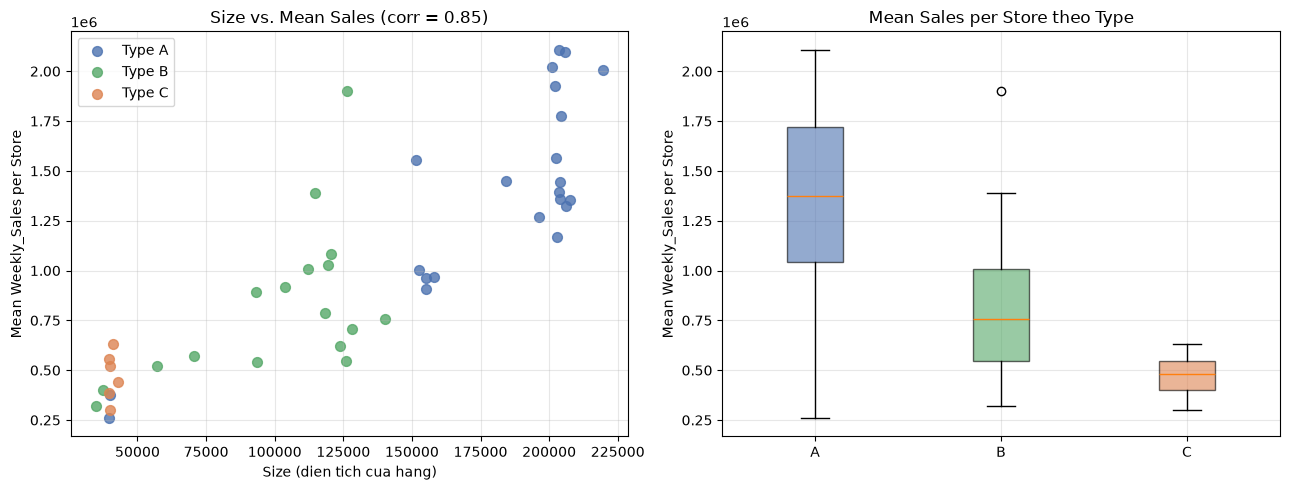

Tuong quan Size vs. mean_sales: 0.846
              mean            std            min           max
Type                                                          
A     1.376673e+06  507385.964811  259861.692028  2.107677e+06
B     8.229950e+05  390897.036418  318011.810490  1.899425e+06
C     4.726148e+05  120459.240233  302748.866014  6.333247e+05


In [8]:
# Size la bien giai thich manh hon Type (kiem chung tuong quan)
summary = (
    train_plot.groupby("Store")
    .agg(mean_sales=("Weekly_Sales", "mean"), Size=("Size", "first"), Type=("Type", "first"))
    .reset_index()
)
corr = summary[["mean_sales", "Size"]].corr().iloc[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

type_colors = {"A": COLOR_NORMAL, "B": COLOR_ACCENT, "C": COLOR_HOLIDAY}
for t, sub in summary.groupby("Type"):
    axes[0].scatter(sub["Size"], sub["mean_sales"], label=f"Type {t}", color=type_colors[t], s=50, alpha=0.8)
axes[0].set_xlabel("Size (dien tich cua hang)")
axes[0].set_ylabel("Mean Weekly_Sales per Store")
axes[0].set_title(f"Size vs. Mean Sales (corr = {corr:.2f})")
axes[0].legend()

box_data = [summary.loc[summary["Type"] == t, "mean_sales"] for t in ["A", "B", "C"]]
bp = axes[1].boxplot(box_data, tick_labels=["A", "B", "C"], patch_artist=True)
for patch, t in zip(bp["boxes"], ["A", "B", "C"]):
    patch.set_facecolor(type_colors[t])
    patch.set_alpha(0.6)
axes[1].set_title("Mean Sales per Store theo Type")
axes[1].set_ylabel("Mean Weekly_Sales per Store")

fig.tight_layout()
plt.show()

print(f"Tuong quan Size vs. mean_sales: {corr:.3f}")
print(summary.groupby("Type")["mean_sales"].describe()[["mean", "std", "min", "max"]])

### 2a. Do bien dong khac nhau ro ret giua cac Store

He so bien dong (CV = std/mean) cho biet Store nao "on dinh" vs. "khong doan truoc duoc" —
lien he truc tiep den do rong khoang tin cay Conformal Prediction (Giai doan 6b): Store CV
cao nen co interval rong hon.

**Vi sao bieu do cot ben duoi co 2 mau (xanh va cam)?** Day KHONG phai phan loai theo
Type cua hang (A/B/C) — ma la **nguong thong ke tren chinh phan phoi CV**: cot **cam**
la 10% Store co CV cao nhat (tren percentile 90, tuc "bien dong manh nhat, kho du bao
nhat"), cot **xanh** la 90% Store con lai (CV thap/trung binh, "on dinh hon"). Muc dich
chi la lam noi bat truc quan nhom Store can luu y khi thiet ke do rong conformal interval,
khong phai mot bien phan loai nghiep vu.

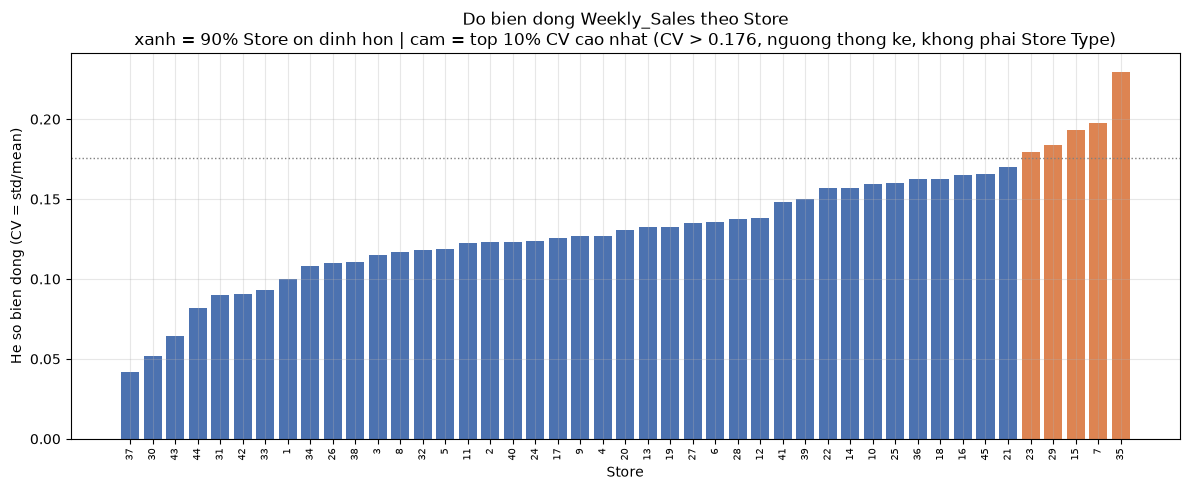

Nguong phan mau (percentile 90 cua CV): 0.176
Top 5 Store bien dong nhat:
Store
35    0.229681
7     0.197305
15    0.193384
29    0.183742
23    0.179721
Name: Weekly_Sales, dtype: float64

Top 5 Store on dinh nhat:
Store
37    0.042084
30    0.052008
43    0.064104
44    0.081793
31    0.090161
Name: Weekly_Sales, dtype: float64


In [9]:
cv = train_plot.groupby("Store")["Weekly_Sales"].agg(lambda s: s.std() / s.mean()).sort_values()
cv_p90 = cv.quantile(0.9)

# Mau chi la nguong thong ke tren phan phoi CV (khong phai Store Type):
# cam = top 10% CV cao nhat (Store bien dong manh), xanh = 90% con lai (on dinh hon).
fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = [COLOR_HOLIDAY if v > cv_p90 else COLOR_NORMAL for v in cv.values]
ax.bar(cv.index.astype(str), cv.values, color=bar_colors)
ax.axhline(cv_p90, color="grey", ls=":", lw=1)
ax.set_xlabel("Store")
ax.set_ylabel("He so bien dong (CV = std/mean)")
ax.set_title(
    f"Do bien dong Weekly_Sales theo Store\n"
    f"xanh = 90% Store on dinh hon | cam = top 10% CV cao nhat (CV > {cv_p90:.3f}, nguong thong ke, khong phai Store Type)"
)
ax.tick_params(axis="x", rotation=90, labelsize=7)
fig.tight_layout()
plt.show()

print(f"Nguong phan mau (percentile 90 cua CV): {cv_p90:.3f}")
print("Top 5 Store bien dong nhat:")
print(cv.sort_values(ascending=False).head())
print("\nTop 5 Store on dinh nhat:")
print(cv.sort_values().head())

### 2b. `IsHoliday` lech pha voi dinh sales that (da ghi vao docs/00_decisions.md)

**Day khong chi la minh hoa lai so lieu cu.** Bar chart duoi day tach rieng tung tuan le
cu the (khong gop chung `IsHoliday=True/False`) - se lo ro mot van de domain: tuan chua
ngay Christmas thuc te (24/12) khong duoc gan co `IsHoliday=True`, trong khi tuan sau do
(31/12) lai duoc gan co nhung sales lai THAP nhat thang. Dieu nay anh huong truc tiep y
nghia cua trong so WMAE/WMAPE x5 dang dung. Da ghi nhan chinh thuc thanh quyet dinh kien
truc muc "[2026-08-19] Ghi nhan `IsHoliday` lech pha voi dinh sales Christmas that" trong
`docs/00_decisions.md` - co che xu ly cu the de danh cho Giai doan 3 (Feature Engineering).

In [ ]:
agg_by_date = train_agg.groupby("Date", as_index=False).agg(
    Weekly_Sales=("Weekly_Sales", "mean"), IsHoliday=("IsHoliday", "first")
)

fig, ax = plt.subplots(figsize=(13, 5))
colors_bar = [COLOR_HOLIDAY if h else COLOR_NORMAL for h in agg_by_date["IsHoliday"]]
ax.bar(agg_by_date["Date"], agg_by_date["Weekly_Sales"], color=colors_bar, width=5)
ax.set_title("Mean Weekly_Sales theo tuan - mau cam = IsHoliday=True")
ax.set_ylabel("Mean Weekly_Sales (theo Store)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Ghi ro ngay thang (yyyy-mm-dd) ngay tren tung thanh IsHoliday=True -- de doc ra
# lech pha ma khong can doi chieu bang text rieng ben duoi.
holiday_rows = agg_by_date[agg_by_date["IsHoliday"]].sort_values("Date")
y_span = agg_by_date["Weekly_Sales"].max() - agg_by_date["Weekly_Sales"].min()
for _, row in holiday_rows.iterrows():
    ax.annotate(
        row["Date"].strftime("%Y-%m-%d"),
        xy=(row["Date"], row["Weekly_Sales"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=6.5,
        rotation=90,
        color=COLOR_HOLIDAY,
    )
ax.set_ylim(top=agg_by_date["Weekly_Sales"].max() + y_span * 0.25)

fig.tight_layout()
plt.show()

**Bang tra cuu: 13 ngay (tuan ket thuc) duoc gan `IsHoliday=True` trong toan bo du lieu**
(doi chieu `data/raw/features.csv`, khop voi bang trong `docs/00_decisions.md`):

| Ngay (tuan ket thuc) | Le tuong ung | Lech pha? |
|---|---|---|
| 2010-02-12 | Super Bowl | Khong |
| 2010-09-10 | Labor Day | Khong |
| 2010-11-26 | Thanksgiving | Khong |
| 2010-12-31 | Christmas | **Co** - dinh sales that la tuan chua 24/12, khong duoc gan co |
| 2011-02-11 | Super Bowl | Khong |
| 2011-09-09 | Labor Day | Khong |
| 2011-11-25 | Thanksgiving | Khong |
| 2011-12-30 | Christmas | **Co** - tuong tu 2010 |
| 2012-02-10 | Super Bowl | Khong |
| 2012-09-07 | Labor Day | Khong |
| 2012-11-23 | Thanksgiving | Khong |
| 2012-12-28 | Christmas | **Co** - tuong tu 2010 |
| 2013-02-08 | Super Bowl | Khong |

In [ ]:
# Zoom vao thang 12 hang nam - so sanh tuan Christmas that (24/12) vs. tuan IsHoliday=True (~31/12)
dec_data = agg_by_date[agg_by_date["Date"].dt.month == 12].copy()
dec_data["day"] = dec_data["Date"].dt.day
dec_data["year"] = dec_data["Date"].dt.year

fig, ax = plt.subplots(figsize=(11, 5))
for yr, sub in dec_data.groupby("year"):
    sub = sub.sort_values("Date")
    ax.plot(sub["day"], sub["Weekly_Sales"], marker="o", label=f"Thang 12/{yr}")
    holiday_pt = sub[sub["IsHoliday"]]
    ax.scatter(holiday_pt["day"], holiday_pt["Weekly_Sales"], color=COLOR_HOLIDAY, s=120,
               zorder=5, marker="*", label=f"_IsHoliday=True {yr}" if yr == dec_data['year'].min() else None)
    # Ghi ro ngay thang (yyyy-mm-dd) ngay canh diem sao cam de thay ngay lech pha
    # so voi vach 24/12, khong phai chi suy tu vi tri tren truc x.
    for _, row in holiday_pt.iterrows():
        ax.annotate(
            row["Date"].strftime("%Y-%m-%d"),
            xy=(row["day"], row["Weekly_Sales"]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=8,
            color=COLOR_HOLIDAY,
            fontweight="bold",
        )

ax.axvline(24, color="grey", ls="--", lw=1, alpha=0.7, label="Ngay 24/12 (Christmas that)")
ax.set_xlabel("Ngay trong thang 12")
ax.set_ylabel("Mean Weekly_Sales")
ax.set_title("Thang 12: dinh sales that (~24/12) vs. tuan duoc gan co IsHoliday=True (sao cam, co ghi ngay)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print("Sales cac tuan thang 12 (tat ca nam):")
print(dec_data.sort_values("Date")[["Date", "Weekly_Sales", "IsHoliday"]].to_string(index=False))

**Nhan xet (can dua vao hop quyet dinh kien truc tiep theo):** day la dac diem da biet
cua bo Walmart Kaggle goc (dinh nghia "tuan chua ngay le" theo lich khong khop tuan mua
sam thuc te), nhung chua duoc ghi nhan trong `docs/00_decisions.md`/`01_ideation.md` truoc
notebook nay. Anh huong: trong so WMAE x5 dang thuong nham tuan it bien dong (31/12) thay
vi tuan bien dong manh nhat nam (24/12). Xem them muc 3 (outlier) va muc 7 (checklist).

## 3. Autocorrelation & tinh hop ly cua lag/rolling da chon

Kiem chung truc quan cac lag da hard-code trong `features/pipeline.py`
(`DEFAULT_LAGS = [1, 4, 12, 26, 52]`) co bat dung chu ky khong, dac biet lag_52
(yearly seasonality).

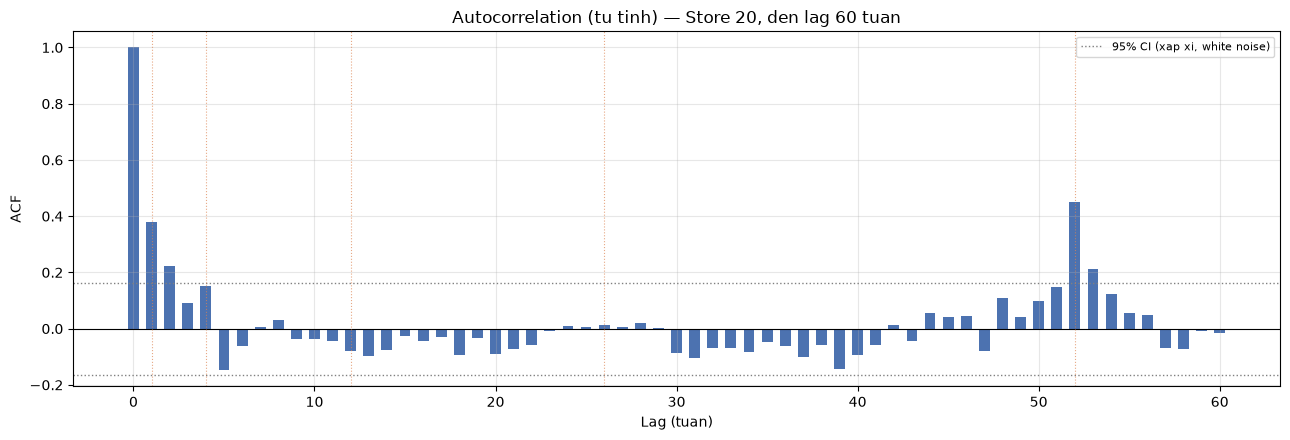

Vach cam net dut = cac lag da chon trong DEFAULT_LAGS (features/pipeline.py)
ACF tai cac lag da chon: {1: 0.38, 4: 0.153, 12: -0.079, 26: 0.011, 52: 0.449}


In [12]:
sample_store = 20
s = train_agg[train_agg["Store"] == sample_store].sort_values("Date").set_index("Date")["Weekly_Sales"]


def acf_manual(series: pd.Series, max_lag: int) -> np.ndarray:
    """Tu tinh ACF bang cong thuc chuan (Pearson corr giua series va ban dich lag k),
    khong dung statsmodels (chua co trong pyproject.toml)."""
    x = series.to_numpy(dtype=float)
    x = x - x.mean()
    n = len(x)
    denom = np.sum(x**2)
    return np.array([np.sum(x[:n - k] * x[k:]) / denom if k > 0 else 1.0 for k in range(max_lag + 1)])


max_lag = 60
acf_vals = acf_manual(s, max_lag)
# Bien can xap xi 95% CI cho white noise: +/- 1.96/sqrt(n)
ci = 1.96 / np.sqrt(len(s))

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.bar(range(max_lag + 1), acf_vals, color=COLOR_NORMAL, width=0.6)
ax.axhline(ci, color="grey", ls=":", lw=1, label="95% CI (xap xi, white noise)")
ax.axhline(-ci, color="grey", ls=":", lw=1)
ax.axhline(0, color="black", lw=0.8)
for lag in [1, 4, 12, 26, 52]:
    ax.axvline(lag, color=COLOR_HOLIDAY, ls=":", lw=0.8, alpha=0.7)
ax.set_xlabel("Lag (tuan)")
ax.set_ylabel("ACF")
ax.set_title(f"Autocorrelation (tu tinh) — Store {sample_store}, den lag {max_lag} tuan")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print("Vach cam net dut = cac lag da chon trong DEFAULT_LAGS (features/pipeline.py)")
print(f"ACF tai cac lag da chon: {dict(zip([1,4,12,26,52], [round(acf_vals[l], 3) for l in [1,4,12,26,52]]))}")

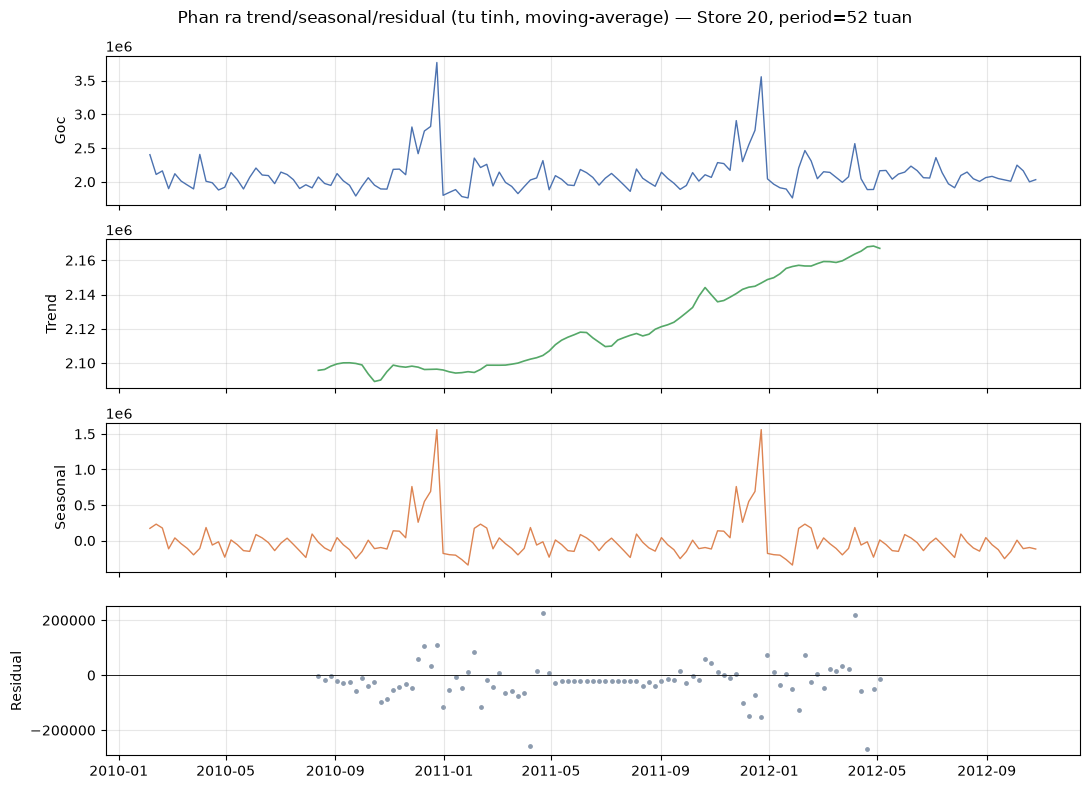

In [13]:
def moving_average_centered(x: np.ndarray, window: int) -> np.ndarray:
    """Trend = moving average tam giac 2xwindow (chuan cho seasonal decomposition
    voi period chan), tu cai bang numpy thuan (khong dung statsmodels)."""
    s = pd.Series(x)
    ma = s.rolling(window, center=True).mean()
    ma2 = ma.rolling(2, center=True).mean()
    return ma2.to_numpy()


s_weekly = s.asfreq("W-FRI").interpolate()  # chi de ve, khong dung lam feature san xuat
x = s_weekly.to_numpy(dtype=float)
period = 52

trend = moving_average_centered(x, period)
detrended = x - trend

# Seasonal component: trung binh detrended theo tung vi tri trong chu ky (52 tuan)
season_idx = np.arange(len(x)) % period
seasonal_avg = pd.Series(detrended).groupby(season_idx).mean()
seasonal = seasonal_avg[season_idx].to_numpy()
seasonal = seasonal - seasonal.mean()  # chuan hoa tong = 0

resid = x - trend - seasonal

fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
axes[0].plot(s_weekly.index, x, color=COLOR_NORMAL, lw=1)
axes[0].set_ylabel("Goc")
axes[1].plot(s_weekly.index, trend, color=COLOR_ACCENT, lw=1.2)
axes[1].set_ylabel("Trend")
axes[2].plot(s_weekly.index, seasonal, color=COLOR_HOLIDAY, lw=1)
axes[2].set_ylabel("Seasonal")
axes[3].scatter(s_weekly.index, resid, color=COLOR_MUTED, s=6)
axes[3].axhline(0, color="black", lw=0.6)
axes[3].set_ylabel("Residual")
fig.suptitle(f"Phan ra trend/seasonal/residual (tu tinh, moving-average) — Store {sample_store}, period=52 tuan")
fig.tight_layout()
plt.show()

## 4. Bien ngoai sinh (Macro & MarkDown) — quan he voi target

Luu y: day la khao sat tuong quan bang mat, KHONG phai ket luan nhan qua (se lam ky hon o
TreeSHAP dependence plot, Giai doan 8).

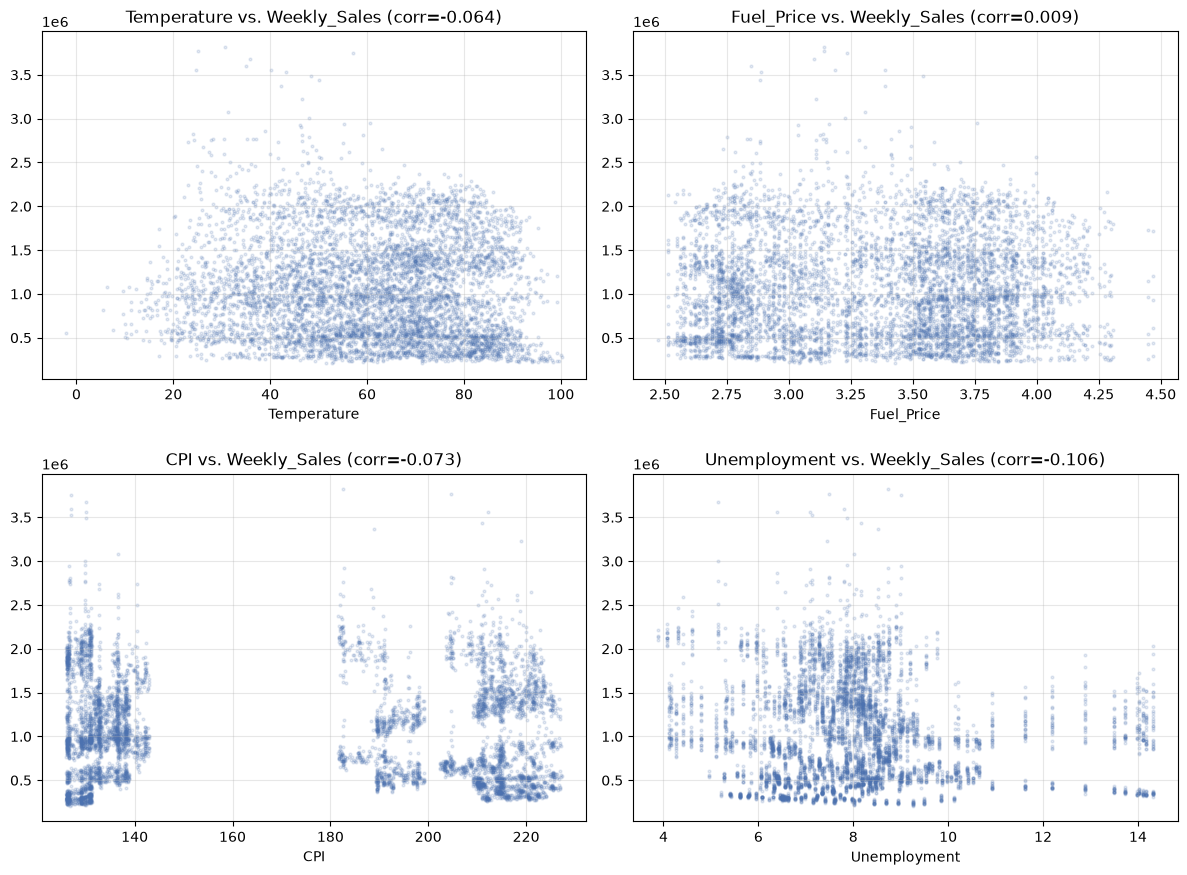

In [14]:
features_by_store_date = raw["features"][["Store", "Date", "Temperature", "Fuel_Price", "CPI", "Unemployment"]]
merged = train_agg.merge(features_by_store_date, on=["Store", "Date"], how="left")

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
macro_cols = ["Temperature", "Fuel_Price", "CPI", "Unemployment"]
for ax, col in zip(axes.ravel(), macro_cols):
    ax.scatter(merged[col], merged["Weekly_Sales"], s=4, alpha=0.15, color=COLOR_NORMAL)
    corr = merged[[col, "Weekly_Sales"]].corr().iloc[0, 1]
    ax.set_title(f"{col} vs. Weekly_Sales (corr={corr:.3f})")
    ax.set_xlabel(col)
fig.tight_layout()
plt.show()

### 4a. MarkDown la 1 campaign dong loat, khong phai 5 cot doc lap (PHAT HIEN MOI)

Ca 5 cot MarkDown1-5 deu bat dau co gia tri dung cung 1 ngay — day la bang chung mot
chuong trinh khuyen mai trien khai dong loat, khong phai missing ngau nhien tung cot.

Ngay bat dau co gia tri (non-null dau tien) theo tung cot MarkDown:
  MarkDown1: 2011-11-11  (missing=50.8%)
  MarkDown2: 2011-11-11  (missing=64.3%)
  MarkDown3: 2011-11-11  (missing=55.9%)
  MarkDown4: 2011-11-11  (missing=57.7%)
  MarkDown5: 2011-11-11  (missing=50.5%)


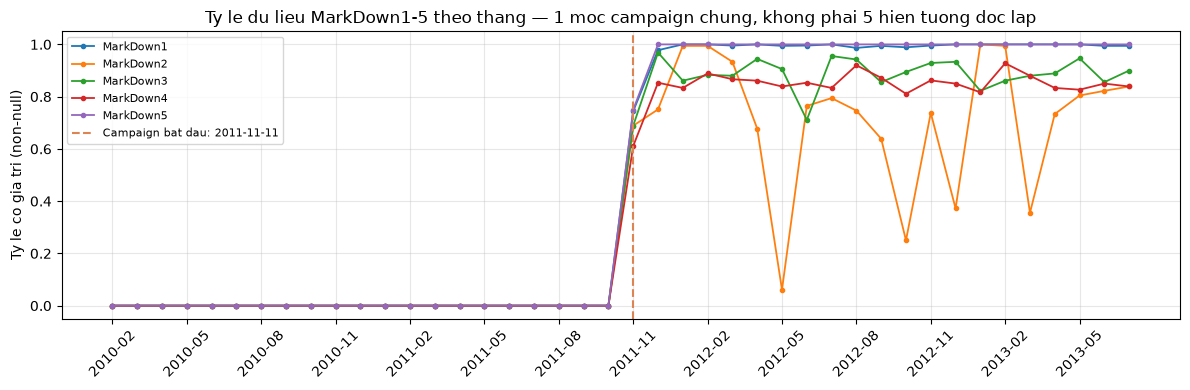

In [15]:
markdown_cols = [c for c in raw["features"].columns if c.startswith("MarkDown")]
first_valid = {c: raw["features"].loc[raw["features"][c].notna(), "Date"].min() for c in markdown_cols}
pct_missing = {c: raw["features"][c].isna().mean() for c in markdown_cols}

print("Ngay bat dau co gia tri (non-null dau tien) theo tung cot MarkDown:")
for c in markdown_cols:
    print(f"  {c}: {first_valid[c].date()}  (missing={pct_missing[c]:.1%})")

fig, ax = plt.subplots(figsize=(12, 4))
avail = raw["features"].assign(year_month=raw["features"]["Date"].dt.to_period("M"))
avail_rate = avail.groupby("year_month")[markdown_cols].apply(lambda g: g.notna().mean())

for c in markdown_cols:
    ax.plot(avail_rate.index.astype(str), avail_rate[c], marker=".", label=c, lw=1.3)

campaign_start = min(first_valid.values())
ax.axvline(str(pd.Period(campaign_start, freq="M")), color=COLOR_HOLIDAY, ls="--",
           label=f"Campaign bat dau: {campaign_start.date()}")
ax.set_xticks(ax.get_xticks()[::3])
ax.tick_params(axis="x", rotation=45)
ax.set_ylabel("Ty le co gia tri (non-null)")
ax.set_title("Ty le du lieu MarkDown1-5 theo thang — 1 moc campaign chung, khong phai 5 hien tuong doc lap")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### 4b. So sanh sales co/khong MarkDown — tach theo giai doan de tranh nham lan

Vi MarkDown chi ton tai tu campaign_start tro di, so sanh truc tiep "co markdown" vs
"khong markdown" tren toan bo lich su se nham lan voi trend chung theo thoi gian. Chi so
sanh trong cung giai doan hau-campaign.

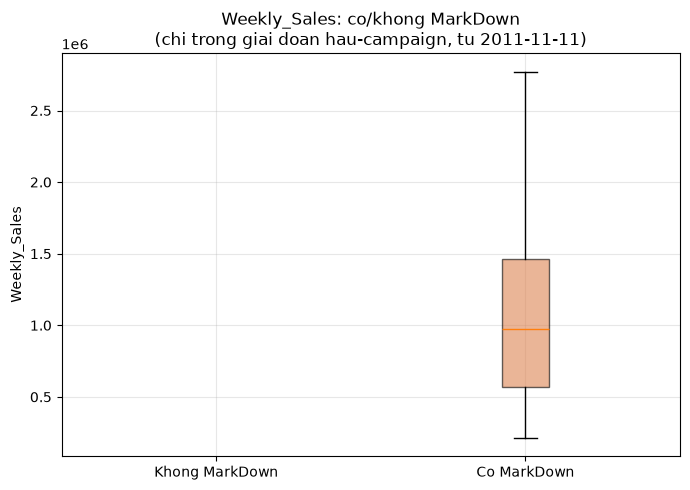

                      mean        50%   count
has_markdown                                 
True          1.067415e+06  976436.02  2295.0


In [16]:
features_flagged = raw["features"].copy()
features_flagged["has_markdown"] = features_flagged[markdown_cols].notna().any(axis=1)

post_campaign = train_agg[train_agg["Date"] >= campaign_start]
merged_post = post_campaign.merge(
    features_flagged[["Store", "Date", "has_markdown"]], on=["Store", "Date"], how="left"
)

fig, ax = plt.subplots(figsize=(7, 5))
box_data = [
    merged_post.loc[merged_post["has_markdown"] == False, "Weekly_Sales"],
    merged_post.loc[merged_post["has_markdown"] == True, "Weekly_Sales"],
]
bp = ax.boxplot(box_data, tick_labels=["Khong MarkDown", "Co MarkDown"], patch_artist=True, showfliers=False)
for patch, c in zip(bp["boxes"], [COLOR_NORMAL, COLOR_HOLIDAY]):
    patch.set_facecolor(c)
    patch.set_alpha(0.6)
ax.set_title(f"Weekly_Sales: co/khong MarkDown\n(chi trong giai doan hau-campaign, tu {campaign_start.date()})")
ax.set_ylabel("Weekly_Sales")
fig.tight_layout()
plt.show()

print(merged_post.groupby("has_markdown")["Weekly_Sales"].describe()[["mean", "50%", "count"]])

## 5. Kiem tra truc quan cac rang buoc thoi gian (bo tro cho `tests/`, khong thay the)

Ve timeline `train_window`/`valid_window`/`test_window` tren 1 truc — xac nhan bang mat
cac moc da do trong `docs/00_decisions.md` (train ket thuc 2011-12-30, valid bat dau
2012-01-06, valid ket thuc 2012-10-26, test.csv that bat dau 2012-11-02).

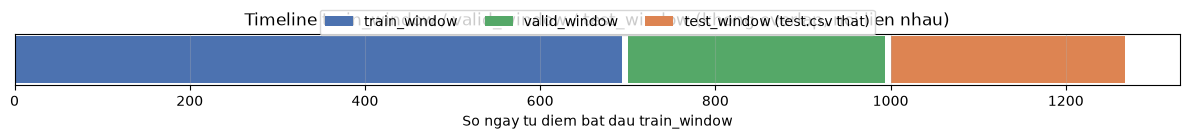

train_window ket thuc: 2011-12-30
valid_window: 2012-01-06 -> 2012-10-26
test_window (that) bat dau: 2012-11-02
Gap train->valid: 7 ngay
Gap valid->test: 7 ngay


In [17]:
import yaml

data_cfg = yaml.safe_load((REPO_ROOT / "configs" / "data.yaml").read_text(encoding="utf-8"))
train_end = pd.Timestamp(data_cfg["temporal_split"]["train_end_date"])
valid_end = pd.Timestamp(data_cfg["temporal_split"]["valid_end_date"])

train_max = train_agg[train_agg["Date"] <= train_end]["Date"].max()
valid_dates = train_agg[(train_agg["Date"] > train_end) & (train_agg["Date"] <= valid_end)]["Date"]
test_min = test_agg["Date"].min()

fig, ax = plt.subplots(figsize=(12, 2.2))
windows = [
    ("train_window", train_agg["Date"].min(), train_max, COLOR_NORMAL),
    ("valid_window", valid_dates.min(), valid_dates.max(), COLOR_ACCENT),
    ("test_window (test.csv that)", test_min, test_agg["Date"].max(), COLOR_HOLIDAY),
]
for i, (label, start, end, c) in enumerate(windows):
    ax.barh(0, (end - start).days, left=(start - windows[0][1]).days, height=0.5, color=c, label=label)

ax.set_yticks([])
ax.set_xlabel("So ngay tu diem bat dau train_window")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.6), ncol=3)
ax.set_title("Timeline train_window / valid_window / test_window (khong overlap, noi lien nhau)")
fig.tight_layout()
plt.show()

print(f"train_window ket thuc: {train_max.date()}")
print(f"valid_window: {valid_dates.min().date()} -> {valid_dates.max().date()}")
print(f"test_window (that) bat dau: {test_min.date()}")
print(f"Gap train->valid: {(valid_dates.min() - train_max).days} ngay")
print(f"Gap valid->test: {(test_min - valid_dates.max()).days} ngay")

So dong CPI missing: 585
So Store bi anh huong: 45 / 45
Khoang thoi gian missing: 2013-05-03 -> 2013-07-26


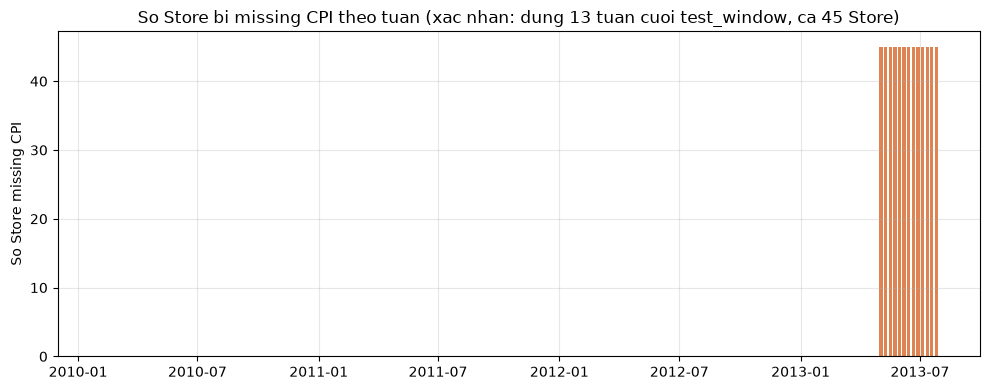

In [18]:
# Phan bo 585 dong CPI/Unemployment missing theo Date x Store
missing_cpi = raw["features"][raw["features"]["CPI"].isna()]
print(f"So dong CPI missing: {len(missing_cpi)}")
print(f"So Store bi anh huong: {missing_cpi['Store'].nunique()} / 45")
print(f"Khoang thoi gian missing: {missing_cpi['Date'].min().date()} -> {missing_cpi['Date'].max().date()}")

fig, ax = plt.subplots(figsize=(10, 4))
missing_by_date = raw["features"].groupby("Date")["CPI"].apply(lambda s: s.isna().sum())
ax.bar(missing_by_date.index, missing_by_date.values, width=5, color=COLOR_HOLIDAY)
ax.set_title("So Store bi missing CPI theo tuan (xac nhan: dung 13 tuan cuoi test_window, ca 45 Store)")
ax.set_ylabel("So Store missing CPI")
fig.tight_layout()
plt.show()

## 6. Error-analysis-readiness — cac nhom cat lat tiem nang

Chuan bi y tuong cho Giai doan 7 (khong tinh chinh thuc o day).

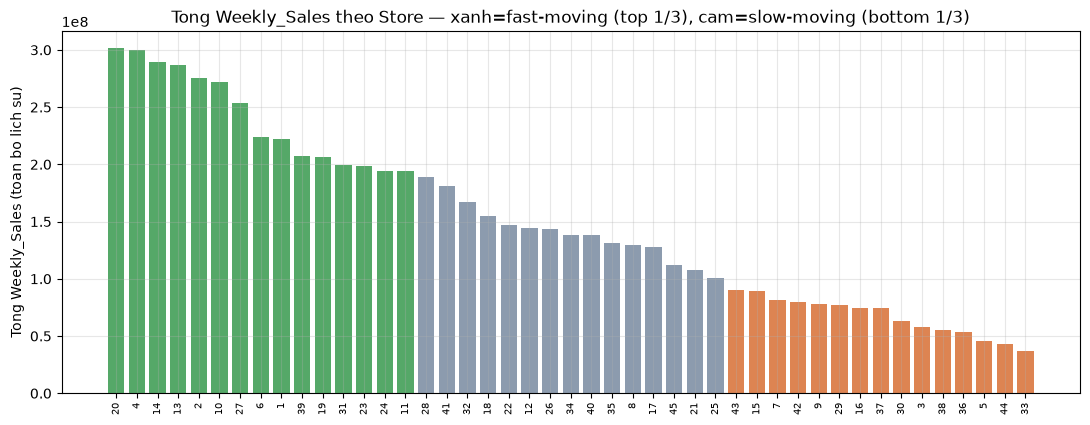

In [19]:
# Phan loai so bo fast/slow-moving Store
store_totals = train_agg.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False)
n = len(store_totals)
fast_moving = store_totals.head(n // 3).index.tolist()
slow_moving = store_totals.tail(n // 3).index.tolist()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(store_totals.index.astype(str), store_totals.values,
       color=[COLOR_ACCENT if s in fast_moving else COLOR_HOLIDAY if s in slow_moving else COLOR_MUTED
              for s in store_totals.index])
ax.set_title("Tong Weekly_Sales theo Store — xanh=fast-moving (top 1/3), cam=slow-moving (bottom 1/3)")
ax.tick_params(axis="x", rotation=90, labelsize=7)
ax.set_ylabel("Tong Weekly_Sales (toan bo lich su)")
fig.tight_layout()
plt.show()

So dong |Weekly_Sales| < 1.0 sau aggregate: 0 / 6435
Weekly_Sales nho nhat (aggregated): 209,986.25


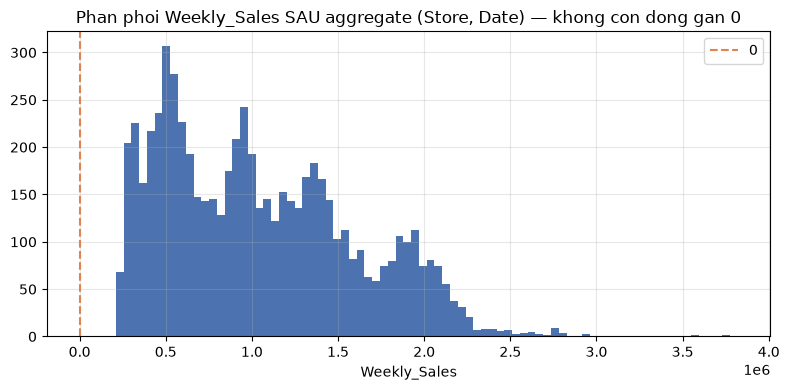

In [20]:
# Xac nhan lai: sau aggregate, con dong Weekly_Sales gan 0 khong?
# (o granularity Dept cu, day la nguyen nhan WMAPE bung no — xem docs/00_decisions.md)
near_zero = train_agg[train_agg["Weekly_Sales"].abs() < 1.0]
print(f"So dong |Weekly_Sales| < 1.0 sau aggregate: {len(near_zero)} / {len(train_agg)}")
print(f"Weekly_Sales nho nhat (aggregated): {train_agg['Weekly_Sales'].min():,.2f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train_agg["Weekly_Sales"], bins=80, color=COLOR_NORMAL)
ax.axvline(0, color=COLOR_HOLIDAY, ls="--", label="0")
ax.set_title("Phan phoi Weekly_Sales SAU aggregate (Store, Date) — khong con dong gan 0")
ax.set_xlabel("Weekly_Sales")
ax.legend()
fig.tight_layout()
plt.show()

### 6a. Boi canh: Dept concentration (khong doi code, chi minh hoa ly do da aggregate)

Minh hoa truc quan ly do quyet dinh gop ve (Store, Date) hop ly — long-tail Dept qua thua
de model hoa rieng (xem `docs/00_decisions.md` [2026-08-19] "Doi don vi du bao").

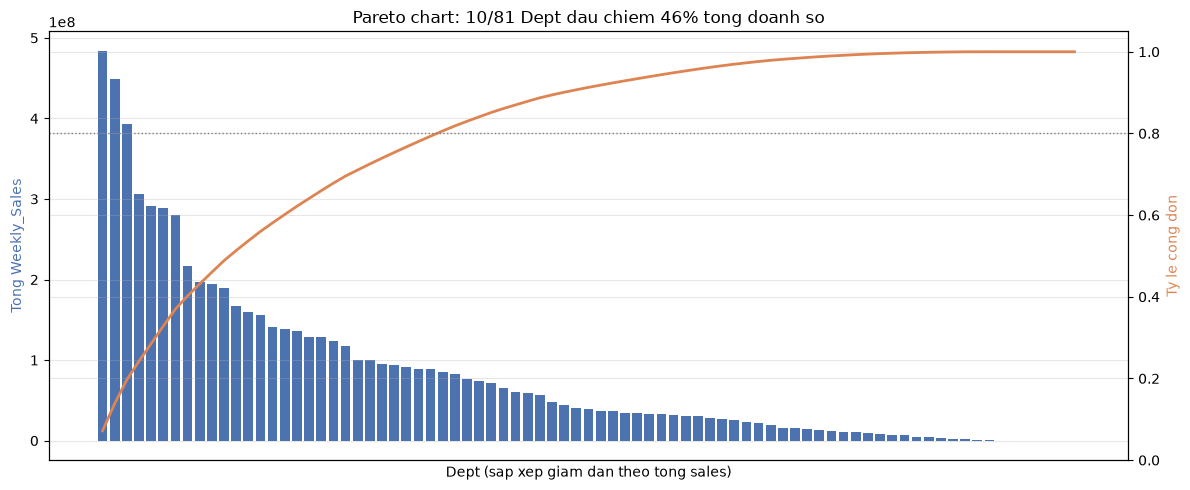

In [21]:
dept_totals = raw["train"].groupby("Dept")["Weekly_Sales"].sum().sort_values(ascending=False)
cum_share = dept_totals.cumsum() / dept_totals.sum()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(range(len(dept_totals)), dept_totals.values, color=COLOR_NORMAL)
ax1.set_xlabel("Dept (sap xep giam dan theo tong sales)")
ax1.set_ylabel("Tong Weekly_Sales", color=COLOR_NORMAL)
ax1.set_xticks([])

ax2 = ax1.twinx()
ax2.plot(range(len(dept_totals)), cum_share.values, color=COLOR_HOLIDAY, lw=2)
ax2.axhline(0.8, color="grey", ls=":", lw=1)
ax2.set_ylabel("Ty le cong don", color=COLOR_HOLIDAY)
ax2.set_ylim(0, 1.05)

n_top10_share = cum_share.iloc[9]
ax1.set_title(f"Pareto chart: 10/{len(dept_totals)} Dept dau chiem {n_top10_share:.0%} tong doanh so")
fig.tight_layout()
plt.show()

## 7. Tong hop phat hien moi → viec can lam tiep

**Checklist phat hien MOI (chua co trong `docs/00_decisions.md`/`01_ideation.md` truoc
notebook nay) — can dua vao hop quyet dinh kien truc tiep theo truoc khi coi la chinh
thuc, dung tinh than CLAUDE.md muc 4 rule 10:**

- [ ] **`IsHoliday` lech pha voi dinh sales that** (muc 2b): tuan 24/12 (dinh sales cao
      nhat nam, tang ~80% so baseline) khong duoc gan co, trong khi tuan ~31/12 (gan co
      True) lai la tuan thap nhat thang 12. Anh huong truc tiep y nghia trong so WMAE x5
      da chot. **Can quyet dinh:** co xu ly gi khong (vd. them flag rieng cho tuan 24/12,
      hoac dieu chinh Calendar block `days_to_next_holiday`) truoc khi implement Giai
      doan 5?
- [ ] **`Size` tuong quan manh voi sales trung binh** (muc 2, corr ~0.85) — manh hon nhieu
      so voi chi dung `Type` categorical roi rac. Can can nhac dung `Size` (continuous)
      lam feature thay vi/them vao `Type`.
- [ ] **Do bien dong (CV) khac nhau ro ret giua 45 Store** (muc 2a, dao dong 0.04-0.23) —
      lien he Giai doan 6b: Conformal interval nen khac nhau theo Store, khong dong deu.
- [ ] **MarkDown la 1 campaign dong loat tu 2011-11-11** (muc 4a) — khong phai 5 hien
      tuong doc lap. Xac nhan lai dung huong `has_markdown` da chot, khong can sua.

**Cac diem da xac nhan khop voi tai lieu (khong phat hien gi moi, chi minh hoa lai):**
- Weekly_Sales am (1,285 dong) va MNAR cua MarkDown — khop `01_ideation.md` muc 2.
- Timeline train/valid/test noi lien khong overlap — khop `00_decisions.md` [2026-08-19]
  "Buffer noi train_window/valid_window".
- 585 dong CPI/Unemployment missing dung 13 tuan cuoi test_window, ca 45 Store — khop
  `00_decisions.md` [2026-08-19] "Xu ly CPI/Unemployment missing".
- Sau aggregate, khong con dong Weekly_Sales gan 0 — khop `progress_week1_2_report.md`.

**Khong dua vao notebook nay (dung tinh than CLAUDE.md rule 8):** thu nghiem feature
engineering hay train thu model — viec do thuoc ve `src/` + `tests/`, chi duoc coi la
chinh thuc sau khi co test tuong ung.